In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

df = pd.read_csv('../data/archive/Disease_symptom_and_patient_profile_dataset.csv')

print(df.shape)
print(df.head())

(349, 10)
       Disease Fever Cough Fatigue Difficulty Breathing  Age  Gender  \
0    Influenza   Yes    No     Yes                  Yes   19  Female   
1  Common Cold    No   Yes     Yes                   No   25  Female   
2       Eczema    No   Yes     Yes                   No   25  Female   
3       Asthma   Yes   Yes      No                  Yes   25    Male   
4       Asthma   Yes   Yes      No                  Yes   25    Male   

  Blood Pressure Cholesterol Level Outcome Variable  
0            Low            Normal         Positive  
1         Normal            Normal         Negative  
2         Normal            Normal         Negative  
3         Normal            Normal         Positive  
4         Normal            Normal         Positive  


In [4]:
print(df.isnull().sum())

# dataset has no missing values

Disease                 0
Fever                   0
Cough                   0
Fatigue                 0
Difficulty Breathing    0
Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Outcome Variable        0
dtype: int64


In [5]:
# frequencies of each disease in the data 

disease_counts = df['Disease'].value_counts()
print(disease_counts)

Disease
Asthma               23
Stroke               16
Osteoporosis         14
Diabetes             10
Migraine             10
                     ..
Schizophrenia         1
Gout                  1
Testicular Cancer     1
Tonsillitis           1
Williams Syndrome     1
Name: count, Length: 116, dtype: int64


There is a clear imbalance in the frequencies of certain diseases compared to others. My model will find a particularly challenging time predicting the diseases that only have a few data entries; ideally this can be fixed with more data later down the line.

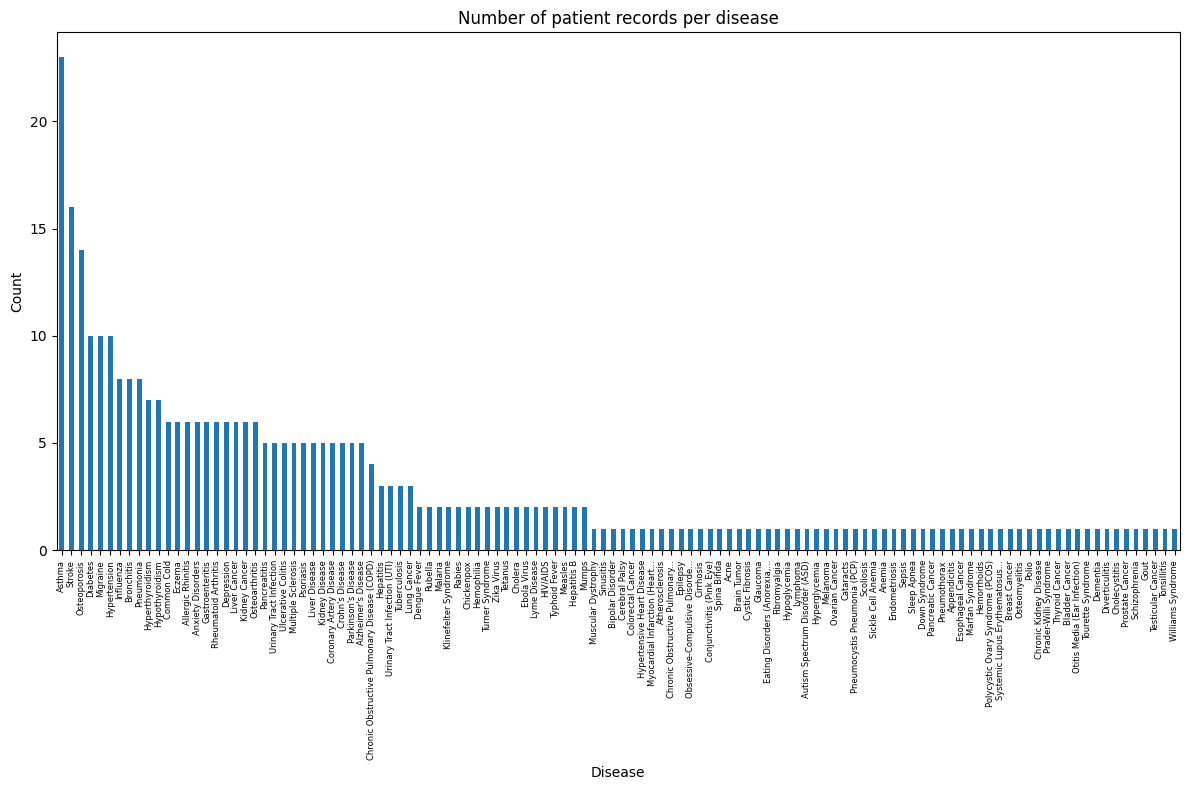

In [8]:
plt.figure(figsize=(12, 8))
disease_counts.plot(kind='bar')
plt.title('Number of patient records per disease')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.xticks(rotation=90, fontsize=6)
plt.tight_layout()
plt.savefig('../data/disease_distribution.png')
plt.show()

More specifically, with only 4 symptoms, data will be inaccurate for the latter half of the diseases in the graphic (the ones with only 1 data entry).

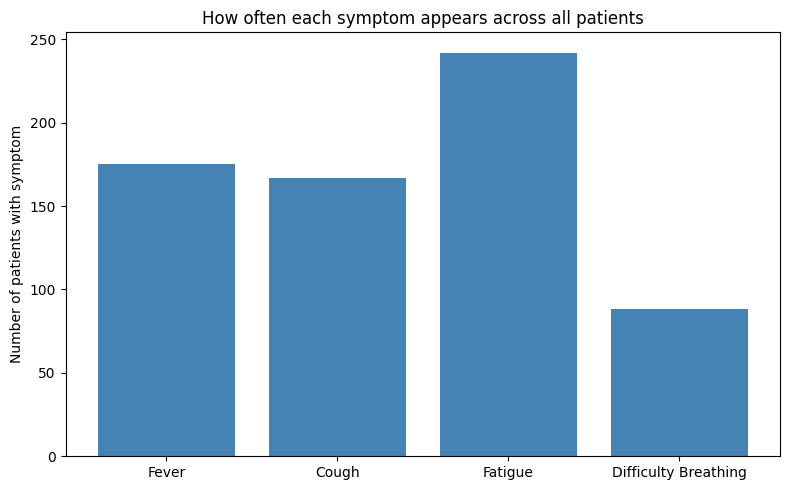

In [9]:
symptom_cols = ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']

symptom_yes = [(df[col] == 'Yes').sum() for col in symptom_cols]

plt.figure(figsize=(8, 5))
plt.bar(symptom_cols, symptom_yes, color='steelblue')
plt.title('How often each symptom appears across all patients')
plt.ylabel('Number of patients with symptom')
plt.tight_layout()
plt.savefig('../data/symptom_frequency.png')
plt.show()

Fatigue has the greatest "yes" frequency, and will likely not be a good diagnostic, whereas difficulty breathing is less common and will allow for more accurate disgnoses.

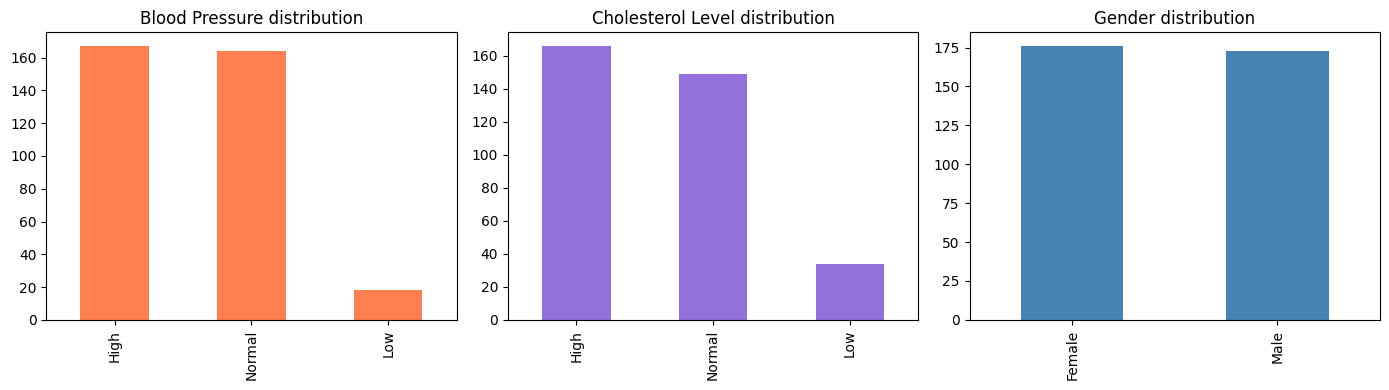

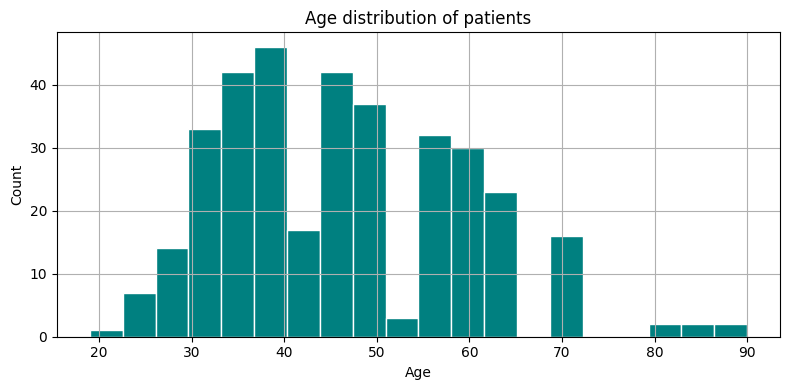

In [10]:
# Visualize the patient profile statistics

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Blood Pressure
df['Blood Pressure'].value_counts().plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Blood Pressure distribution')
axes[0].set_xlabel('')

# Cholesterol
df['Cholesterol Level'].value_counts().plot(kind='bar', ax=axes[1], color='mediumpurple')
axes[1].set_title('Cholesterol Level distribution')
axes[1].set_xlabel('')

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Gender distribution')
axes[2].set_xlabel('')

plt.tight_layout()
plt.savefig('../data/profile_distributions.png')
plt.show()

# Age
plt.figure(figsize=(8, 4))
df['Age'].hist(bins=20, color='teal', edgecolor='white')
plt.title('Age distribution of patients')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../data/age_distribution.png')
plt.show()

Low blood pressure and cholesterol are uncommon, meaning they could be indicative of certain diseases. Ages are relatively normal, with a few older outliers. The variety in blood pressure, cholesterol, and age compared to the yes/no symptom data will mean that the patient profile statistics will carry more predictive weight. 

Feature Matrix:

In [4]:
# Make a copy
df_model = df.copy()

# Convert Yes/No symptoms to 1/0 (yes = 1)
for col in ['Fever', 'Cough', 'Fatigue', 'Difficulty Breathing']:
    df_model[col] = (df_model[col] == 'Yes').astype(int)

# Convert Gender to 0/1 (male = 1)
df_model['Gender'] = (df_model['Gender'] == 'Male').astype(int)

# Convert Blood Pressure to ordered numbers
bp_map = {'Low': 0, 'Normal': 1, 'High': 2}
df_model['Blood Pressure'] = df_model['Blood Pressure'].map(bp_map)

# Convert Cholesterol to ordered numbers
chol_map = {'Low': 0, 'Normal': 1, 'High': 2}
df_model['Cholesterol Level'] = df_model['Cholesterol Level'].map(chol_map)

outcome_map = {'Positive': 1, 'Negative': 0}
df_model['Outcome Variable'] = df_model['Outcome Variable'].map(outcome_map)

# Age stays as is - it's already a number

print(df_model.head())
print(df_model.dtypes)

       Disease  Fever  Cough  Fatigue  Difficulty Breathing  Age  Gender  \
0    Influenza      1      0        1                     1   19       0   
1  Common Cold      0      1        1                     0   25       0   
2       Eczema      0      1        1                     0   25       0   
3       Asthma      1      1        0                     1   25       1   
4       Asthma      1      1        0                     1   25       1   

   Blood Pressure  Cholesterol Level  Outcome Variable  
0               0                  1                 1  
1               1                  1                 0  
2               1                  1                 0  
3               1                  1                 1  
4               1                  1                 1  
Disease                   str
Fever                   int64
Cough                   int64
Fatigue                 int64
Difficulty Breathing    int64
Age                     int64
Gender               

I am including the outcome variable in the feature matrix despite it not being a user input in the app because it will be useful in determining both which diseases may be affecting the patient and also which will not be affecting them.

In [5]:
df_model.to_csv('../data/feature_matrix.csv', index=False)
print("Feature matrix saved — shape:", df_model.shape)

Feature matrix saved — shape: (349, 10)
